In [3]:
# !pip install NeuroKit2
# !pip install wfdb
# !pip install ts2vg

# Documentação
[Documentação Neurokit2](https://neuropsychology.github.io/NeuroKit/)

In [4]:
import pandas as pd
import numpy as np
import wfdb

import matplotlib.pyplot as plt


In [8]:
from google.colab import drive

drive.mount('/content/drive')

link ='/content/drive/MyDrive/UFC_mestrado/Sigaa_UFC/Tese_dissertativo_Mestrado/Projeto_Tese_mestrado/04_Tratamento_dos_dados/analise_estatistico/neurokit_codebook.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
documentacao = pd.read_csv(link)

In [10]:
documentacao

,Field Name,Field Description,Field Category,Source File Name
0,ECG_Raw,The raw signal.,Electrocardiography,ecg_process.py
1,ECG_Clean,The cleaned signal.,Electrocardiography,ecg_process.py
2,ECG_Rate,Heart rate interpolated between R-peaks.,Electrocardiography,ecg_process.py
3,ECG_Quality,The quality of the cleaned signal.,Electrocardiography,ecg_process.py
4,ECG_R_Peaks,"The R-peaks marked as ""1"" in a list of zeros.",Electrocardiography,ecg_process.py
...,...,...,...,...
179,RSP_Rate_Mean,The mean respiratory rate.,Respiration,rsp_intervalrelated.py
180,RSP_Amplitude_Mean,The mean respiratory amplitude.,Respiration,rsp_intervalrelated.py
181,RSP_Phase_Duration_Inspiration,The average inspiration duration.,Respiration,rsp_intervalrelated.py
182,RSP_Phase_Duration_Expiration,The average expiration duration.,Respiration,rsp_intervalrelated.py


In [ ]:
# pegando uma amostra de um paciente
# record = wfdb.rdrecord(r'D:\Projeto_Tese_mestrado\02_Dataset\dados_ECG\High-resolution_ECG\P0001_H')
record = wfdb.rdrecord(r'D:\painel python\projeto\P0001_H')


# Exibir as informações do arquivo
print(record.__dict__)

{'record_name': 'P0001_H', 'n_sig': 3, 'fs': 1000, 'counter_freq': None, 'base_counter': None, 'sig_len': 1196000, 'base_time': None, 'base_date': None, 'comments': [], 'sig_name': ['X', 'Y', 'Z'], 'p_signal': array([[ 0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ],
       ...,
       [ 0.415 ,  0.33  , -1.335 ],
       [ 0.42  ,  0.37  , -1.4125],
       [ 0.4075,  0.395 , -1.46  ]]), 'd_signal': None, 'e_p_signal': None, 'e_d_signal': None, 'file_name': ['P0001_H.dat', 'P0001_H.dat', 'P0001_H.dat'], 'fmt': ['16', '16', '16'], 'samps_per_frame': [1, 1, 1], 'skew': [None, None, None], 'byte_offset': [0, 0, 0], 'adc_gain': [400.0, 400.0, 400.0], 'baseline': [0, 0, 0], 'units': ['mV', 'mV', 'mV'], 'adc_res': [16, 16, 16], 'adc_zero': [0, 0, 0], 'init_value': [None, None, None], 'checksum': [None, None, None], 'block_size': [None, None, None]}


In [ ]:
record.fs

1000

In [ ]:
p_signal = record.p_signal
p_signal

array([[ 0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ],
       ...,
       [ 0.415 ,  0.33  , -1.335 ],
       [ 0.42  ,  0.37  , -1.4125],
       [ 0.4075,  0.395 , -1.46  ]])

In [ ]:
p_signal[:,0]

array([0.    , 0.    , 0.    , ..., 0.415 , 0.42  , 0.4075])

Usando o Neurokit 2

In [ ]:
import neurokit2 as nk


In [ ]:
# Processando os dados
# Aqui contém o pre processamento dos dados
# Primeiro argumento processando os dados por colunas, taxa de amostra significa quanto de amostra.

# Esta função executa diferentes etapas de pré-processamento:
# limpeza (usando ecg_clean()), detecção de pico (usando ecg_peaks()),
# cálculo da frequência cardíaca (usando signal_rate()), avaliação da qualidade do sinal (usando ecg_quality()),
# delineamento do complexo QRS (usando ecg_delineate()) e determinação da fase cardíaca (usando ecg_phase()).

# ecg_signal ( Union[list, np.array, pd.Series] ) – O sinal de ECG de canal único bruto.

# sampling_rate ( int ) – A frequência de amostragem de ecg_signal(em Hz, ou seja, amostras/segundo). O padrão é 1000.

# método ( str ) – O método de processamento usado para limpeza de sinal (usando ecg_clean()) e detecção de pico (usando ecg_peaks()).
# O padrão é 'neurokit'. Os métodos disponíveis são 'neurokit', 'pantompkins1985', 'hamilton2002', 'elgendi2010', 'engzeemod2012'.

# Para essa amostra a taxa de frequencia é 1000, e está contida no record.fs

# 'amostra' seja o retorno de nk.ecg_process()

df_resultado, dict_info = nk.ecg_process(p_signal[:,0], sampling_rate=1000, method='neurokit') # Dividindo a tupla em DataFrame e Dicionário

In [ ]:
# Aqui contem os resultados

# sinais ( DataFrame ) – Um DataFrame do mesmo comprimento que o ecg_signalcontendo as seguintes colunas:

# ECG_Raw: O sinal bruto.
# ECG_Clean: O sinal limpo.
# ECG_Rate: Frequência cardíaca interpolada entre picos R.
# ECG_Quality: A qualidade do sinal limpo.
# ECG_R_Peaks: Os picos R marcados como “1” em uma lista de zeros.
# ECG_R_Onsets: Os R-onsets marcados como “1” em uma lista de zeros.
# ECG_R_Offsets: Os deslocamentos R marcados como “1” em uma lista de zeros.
# ECG_P_Peaks: Os picos P marcados como “1” em uma lista de zeros.
# ECG_P_Onsets: Os P-onsets marcados como “1” em uma lista de zeros.
# ECG_P_Offsets: Os deslocamentos P marcados como “1” em uma lista de zeros.
# ECG_Q_Peaks: Os picos Q marcados como “1” em uma lista de zeros.
# ECG_S_Peaks: Os picos S marcados como “1” em uma lista de zeros.
# ECG_T_Peaks: Os picos T marcados como “1” em uma lista de zeros.
# ECG_T_Onsets: Os T-ons marcados como “1” em uma lista de zeros.
# ECG_T_Offsets: Os deslocamentos T marcados como “1” em uma lista de zeros.
# ECG_Phase_Atrial: Fase cardíaca, marcada por “1” para sístole e “0” para diástole.
# ECG_Phase_Completion_Atrial: Conclusão da fase cardíaca (atrial), expressa em porcentagem (de 0 a 1), representando o estágio da fase cardíaca atual.
# ECG_Phase_Completion_Ventricular: Conclusão da fase cardíaca (ventricular), expressa em porcentagem (de 0 a 1), representando o estágio da fase cardíaca atual.

df_resultado

,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,0.0000,0.000296,56.501625,0.490957,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,0.0000,-0.069459,56.501625,0.490957,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,0.0000,-0.139207,56.501625,0.490957,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,0.0000,-0.208944,56.501625,0.490957,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,-0.3175,-0.278692,56.501625,0.490957,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195995,0.4075,-0.163742,53.523640,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1195996,0.4075,-0.157368,53.523640,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1195997,0.4150,-0.151051,53.523640,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1195998,0.4200,-0.144776,53.523640,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


In [ ]:
# rpeaks ( dict ) – Um dicionário contendo as amostras nas quais os picos R ocorrem,
# acessíveis com a tecla "ECG_R_Peaks", bem como a taxa de amostragem dos sinais.
dict_info

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([   1403,    1898,    2490, ..., 1192964, 1193876, 1194997]),
 'ECG_R_Peaks_Uncorrected': array([   1403,    1898,    2490, ..., 1192964, 1193876, 1194997]),
 'ECG_fixpeaks_ectopic': [],
 'ECG_fixpeaks_missed': [],
 'ECG_fixpeaks_extra': [],
 'ECG_fixpeaks_longshort': [],
 'ECG_fixpeaks_method': 'kubios',
 'ECG_fixpeaks_rr': array([1.06191637, 0.495     , 0.592     , ..., 0.999     , 0.912     ,
        1.121     ]),
 'ECG_fixpeaks_drrs': array([ 4.47537415e-05, -4.93872611e-01,  8.65105909e-02, ...,
        -4.28832568e-01, -8.19131908e-02,  1.92192744e-01]),
 'ECG_fixpeaks_mrrs': array([-0.14528595, -1.36491241, -1.06211282, ..., -0.12413512,
        -0.4122288 ,  0.05869053]),
 'ECG_fixpeaks_s12': array([-4.93872611e-01,  4.47537415e-05,  5.84898972e-01, ...,
        -8.19131908e-02, -4.28832568e-01, -8.19131908e-02]),
 'ECG_fixpeaks_s22': array([-0.49387261,  0.58489897, -0.06444293, ...,  0.19219274,
  

#Gráficos

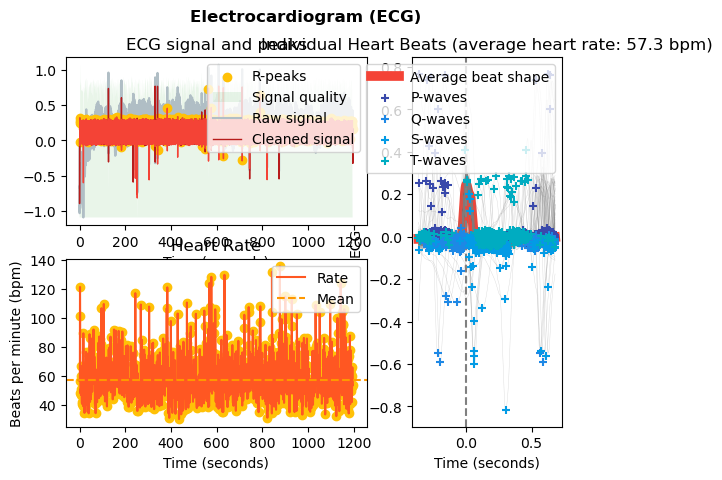

In [ ]:
# Visualizando com gráfico
nk.ecg_plot(df_resultado, dict_info)

In [ ]:
# Configurar o tamanho da figura globalmente
plt.rcParams["figure.figsize"] = (16, 6)  # Ajuste a largura e altura aqui


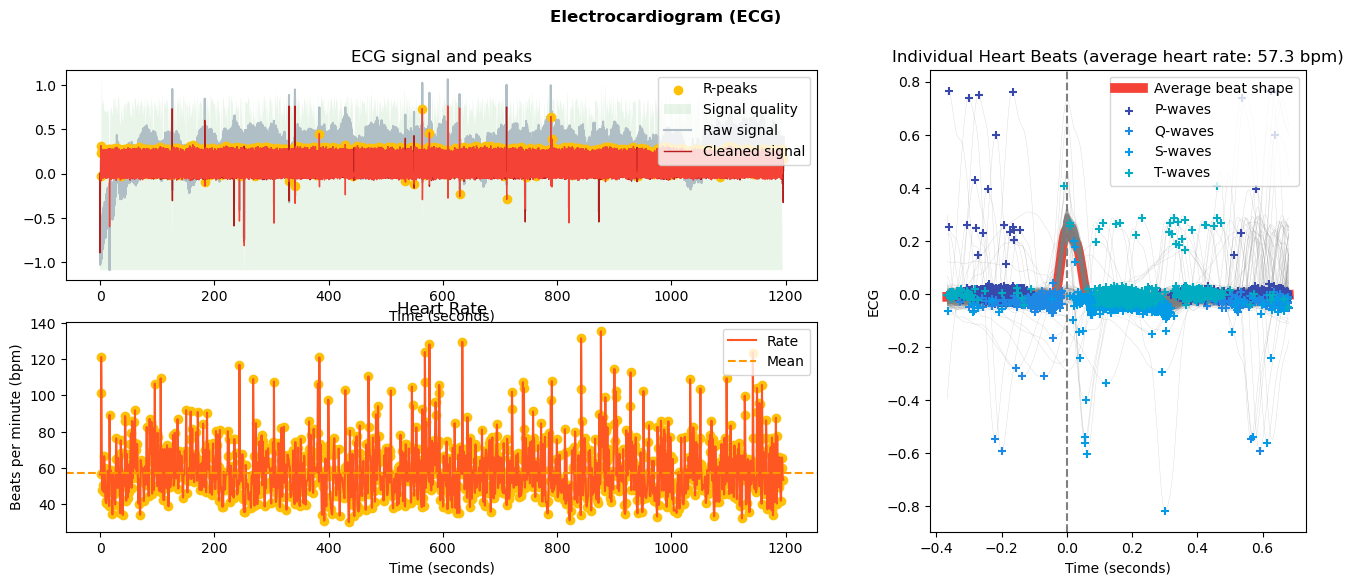

In [ ]:
# Gerar o gráfico de ECG
#plt.figure(figsize=(24, 8))  # Ajuste o tamanho da figura (largura, altura)
nk.ecg_plot(df_resultado, dict_info)

# Exibir o gráfico com o novo tamanho
plt.show()

In [ ]:
# Executa análises de ECG calculando características e índices relevantes em épocas (análise relacionada a eventos)
# ou em períodos mais longos de dados (análise relacionada a intervalos), como dados de estado de repouso.

# DataFrame – Um dataframe contendo as características de ECG analisadas.
# Se for A análise relacionada a eventos é realizada, cada época é indicada pelo LabelUma coluna.
# Ver ecg_eventrelated()E a ecg_intervalrelated()docstrings para detalhes.

# Exemplo 1
# Análise relacionada a Interval-relacionadas
analyze_df = nk.ecg_analyze(df_resultado, sampling_rate=1000, method='auto')
analyze_df

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,57.301374,[[1061.9163701067616]],[[266.9583565811751]],[[46.01677372869354]],[[263.4993356429082]],[[30.62407373370801]],[[265.06447406381346]],[[7.996203363417657]],[[266.9320019783063]],[[362.7131657460492]],...,[[2.1313436566040584]],[[9.199917833168136]],[[1.6149683043251597]],[[0.7384750753956179]],[[1.4304290346445423]],[[2.1299447319343963]],[[1.9053941162377874]],[[1.9930682471965517]],[[4.269585171700112]],[[1.072950829276059]]


In [ ]:
# Exemplo 2
# Análise relacionada a eventos

# Detectando eventos no primeiro canal de p_signal
events = nk.events_find(p_signal[:,0])

# Criando épocas (epochs) com base nos eventos detectados
epochs = nk.epochs_create(df_resultado, events, sampling_rate=1000, epochs_start=-0.1, epochs_end=1.9)

# Analisando as épocas de ECG
analyze_epochs = nk.ecg_analyze(epochs, sampling_rate=1000)

In [ ]:
analyze_epochs

,Label,Event_Onset,ECG_Rate_Baseline,ECG_Rate_Max,ECG_Rate_Min,ECG_Rate_Mean,ECG_Rate_SD,ECG_Rate_Max_Time,ECG_Rate_Min_Time,ECG_Rate_Trend_Linear,ECG_Rate_Trend_Quadratic,ECG_Rate_Trend_R2,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular,ECG_Quality_Mean
1,1,0,56.501625,64.710497,0.000000,8.791625,18.315750,1.898999,0.001051,-54.962287,11.560006,0.844140,NaN,0.000000,NaN,0.000000,0.448941
2,2,25062,45.703585,-0.004624,-5.862948,-3.610813,1.834333,0.001051,1.515808,-10.663334,1.134335,0.845884,1.0,0.964758,0.0,0.992467,0.949978
3,3,25070,45.666695,0.218831,-5.826058,-3.573499,1.835179,1.900000,1.507804,-10.839471,1.166129,0.836748,1.0,1.000000,0.0,1.000000,0.949836
4,4,26561,39.841757,36.591364,-0.001120,21.369881,13.092217,1.726913,0.016058,39.593156,-5.932337,0.982520,1.0,0.917127,0.0,0.987942,0.958613
5,5,26601,39.866768,36.566353,0.002205,22.066919,12.836816,1.686893,0.001051,42.111853,-5.647095,0.984392,0.0,0.032922,1.0,0.016913,0.958557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,3323,1055296,50.596175,0.036736,-1.302471,-0.497711,0.413286,0.077089,1.900000,-0.394783,0.100644,0.997192,1.0,0.573034,0.0,0.916758,0.950755
3324,3324,1055329,50.620677,0.012234,-1.358558,-0.545368,0.421237,0.044072,1.900000,-0.438520,0.076820,0.998031,1.0,0.758427,0.0,0.952903,0.950183
3325,3325,1055341,50.626395,0.006516,-1.375574,-0.559730,0.423917,0.032066,1.900000,-0.452351,0.070157,0.998237,1.0,0.825843,0.0,0.966046,0.949972
3326,3326,1055457,50.626066,-0.000161,-1.478006,-0.646917,0.445838,0.001051,1.900000,-0.560475,0.043918,0.999269,0.0,0.081871,1.0,0.166667,0.947920


In [ ]:
# Para função events = nk.events_find(p_signal[:,0])

# Encontre e selecione eventos em um sinal contínuo (por exemplo, de um sensor de fotos).
# Parâmetros:

#  event_channel (array ou lista ou DataFrame) – O canal que contém os eventos. Se vários canais forem inseridos, os canais são tratada como refletindo
#  diferentes eventos novos canais é criado com base neles.
#  limiar (str ou float) – O valor limite pelo qual selecionar os eventos. Se for "auto"- Leva o valor entre o máximo e o min.
#  Se for "auto"é usado com entradas multicanal, o valor padrão de 0,9 é usado para capturar todos os eventos.
#  threshold_keep (str) – "above"ou a "below"definir os eventos como acima ou abaixo do limiar. Para fotosensores, uma tela branca corresponde geralmente a valores mais altos.
#  Portanto, se o seu eventos são sinalizados por uma cor preta,
#  os valores dos eventos são os mais baixos (ou seja, o sinal “gotas” quando os eventos estiverem no início), e você deve definir o corte para "below"- A .
#  (í a , , , , , ínte , .
#  start_at (int) – Manter eventos cujo início é depois de um ponto de tempo específico.
#  end_at (int) – Manter eventos que o início é antes de um ponto de tempo específico.
#  Duração_min (int) – A duração mínima de um evento a ser considerado como tal (em pontos de tempo).
#  Duração_max (int) – A duração máxima de um evento a ser considerado como tal (em pontos de tempo).
#  inter_min (int) – A duração mínima após um evento para o evento subsequente a ser considerado como tal (em pontos de tempo).
#  Uso quando eventos consecutivos espúrios são criados devido a amostragem muito alta de taxa.
#  descar_primo (int) – Descarte os primeiros ou últimos n eventos. É útil se o experimento começa com alguns eventos espúrias. Se for discard_first=0,
#  nenhum primeiro evento é removido.
#  descar_last (int) – Descarte primeiro ou último n eventos. É útil se o experimento termina com alguns eventos espúrios. Se for discard_last=0,
#  nenhum último evento é removido.
#  event_labels (lista) – Uma lista contendo identificadores de eventos únicos. Se for None, usará o número do índice de eventos.
#  event_conditions (list) – Uma lista opcional contendo, para cada evento, por exemplo, a categoria de teste, grupo ou grupo ou as condições experimentais.
#  Esta opção é ignorada quando vários canais são fornecidos, como a função gera isso automaticamente.

#  Devoluções:
#  dict – Dit. contém 3 a 5 arrays, "onset"para o início do evento, "duration"para o evento durações, "label"para os identificadores de eventos,
#  o opcional "condition"Passos por cabo para event_conditionsE o events_channelSe vários canais foram fornecidos para a função.


In [ ]:
# Para Função epochs = nk.epochs_create(df_resultado, events, sampling_rate=100, epochs_start=-0.1, epochs_end=1.9)

# Criar épocas de um sinal ou um dataframe.

# Parâmetros:

#   dados (DataFrame) – Um DataFrame contendo os diferentes sinais (s) como colunas diferentes. Se um vetor de valores for passado,
#   ele será transformado em um DataFrame com uma única coluna “Signal”.
#   eventos (lista ou ndarray ou dict) – Localização de início de eventos. Se um ditado for aprovado (por exemplo, de events_find()) - Em que outra,
#   a sua portado em (í ) irá selecionar apenas a lista de "inset". Se um inteiro é passado, usará esse número para criar uma lista uniformemente espaçada de eventos.
#   Se nenhum, irá bloquear o sinal em blocos sucessivos da duração definida.
#   sampling_rate (int) – A frequência de amostragem do sinal (em Hz, ou seja, amostras/segundo).
#   epochs_start (int, list) – Épocas de início em relação ao events_onsets (em segundos). O início pode ser negativo para começar épocas antes de um determinado evento
#   (ter uma linha de base, por exemplo). Um inteiro pode ser especificado ter o mesmo começo para todas as épocas. Uma lista de igual duração dos eventos pode ser especificado
#   para ter um começo diferente para cada época.
#   epochs_end (int, list) – Epochs terminam em relação a eventos_onsets (em segundos). Um inteiro pode ser especificado para ter o O mesmo fim para todas as épocas.
#   Uma lista de comprimento igual aos eventos pode ser especificada para ter um um fim diferente para cada época. Se for "from_events", os eventos devem ser um ditado
#   (de events_find()) Em que o es., . A duração dos eventos será usada como epochs_end- A . (í a questão: es. , , , í , , .
#   event_labels (lista) – Uma lista contendo identificadores de eventos únicos. Se for None, usará o número do índice de eventos.
#   event_conditions (list) – Uma lista opcional contendo, para cada evento, por exemplo, a categoria de teste, grupo ou grupo ou as condições experimentais.
#   baseline_correction (bool) – Defaults to false.

# Devoluções:

#     dict – Um ditado contendo DataFrames para todas as épocas.

In [ ]:
# Para função analyze_epochs = nk.ecg_analyze(epochs, sampling_rate=100)

# Executa análise de ECG computando recursos e índices relevantes em ambas as épocas (análise relacionada com o evento) ou em períodos mais longos de dados
# (análise relacionada ao intervalo), como dados do estado de repouso.

# Parâmetros:
#   dados (Union[dict, pd.DataFrame]) – Um dicionário de épocas, contendo um DataFrame por época, geralmente obtidos via epochs_create(),
#   ou um DataFrame contendo todas as épocas, geralmente obtidas através de epochs_to_df()- A . (í a , , , , , ínte , .
#   Também pode tomar um DataFrame de sinais processados de um período mais longo de dados, normalmente gerados por ecg_process()ou a bio_process()- A .
#   (í a , , , , , ínte , . Também pode levar um ditado contendo conjuntos de períodos separados de dados.
#   sampling_rate (int) – A frequência de amostragem do sinal (em Hz, ou seja, amostras/segundo). O padrão é de 1000Hz.
#   método (str) – Pode ser um dos "event-related"para análise relacionada a eventos em épocas, ou "interval-related"análise de períodos mais longos de dados.
#   Dem prestântult para auto,, , - A , de frente para o que sobre o que sobre, , sobre o que sobre o que sobre, sobre o que quando o método for escolhido com
#   base na duração média dos dados ( "event-related"por duração inferior a 10s).

# Devoluções:

#     DataFrame – Um dataframe contendo as características de ECG analisadas. Se for A análise relacionada a eventos é realizada, cada época é indicada pelo LabelUma coluna.
#     Ver ecg_eventrelated()E a ecg_intervalrelated()docstrings para detalhes.


In [ ]:
# Gerar um sinal de ECG artificial (sintético) de uma determinada duração e taxa de amostragem usando qualquer o modelo dinâmico ECGSYN (McSharry et al., 2003)
# ou um modelo mais simples baseado em Daubechies wavelets para ciclos cardíacos aproximadamente aproximados.

ecg1 = nk.ecg_simulate(duration=10, method="simple")

ecg2 = nk.ecg_simulate(duration=10, method="ecgsyn")
ecg2

array([1.09495157, 1.09038114, 1.07985016, ..., 0.01498513, 0.01530053,
       0.01569734])

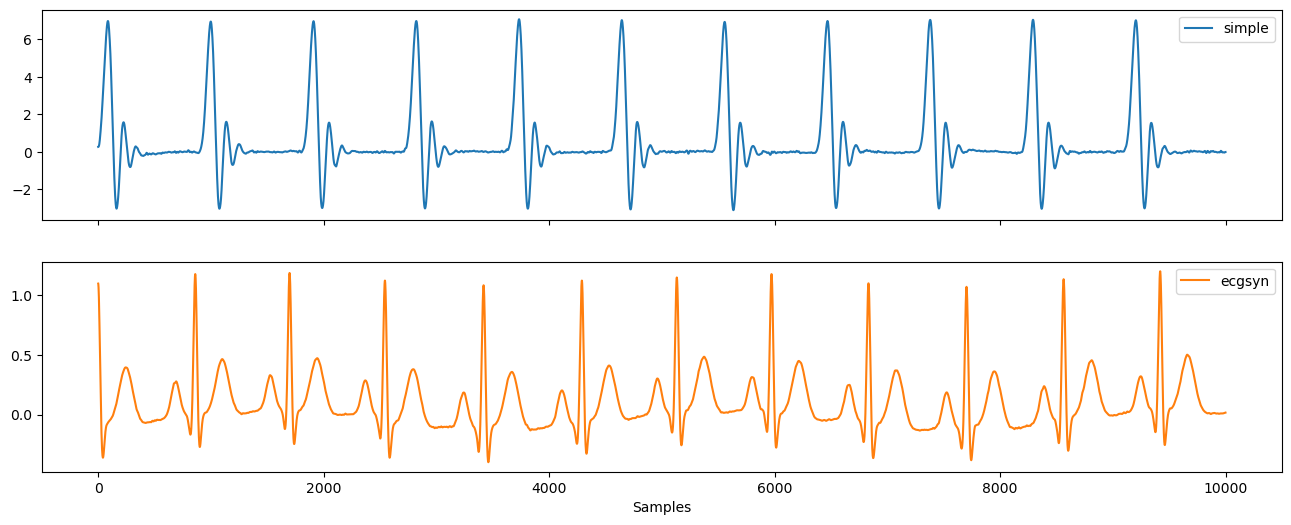

In [ ]:
# Visualize result

nk.signal_plot([ecg1, ecg2], labels=["simple", "ecgsyn"], subplots=True)

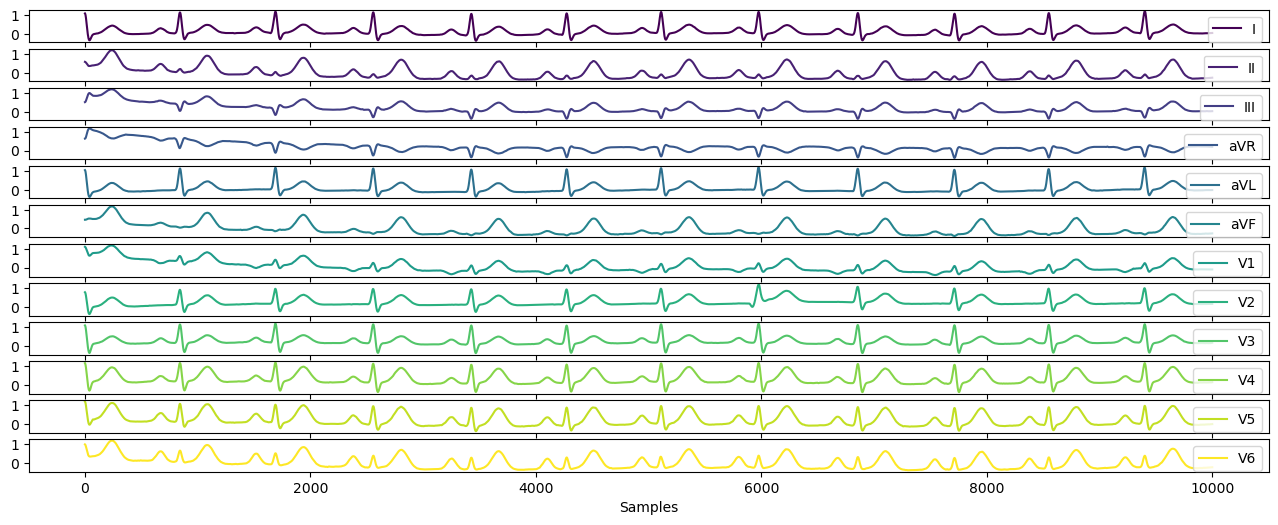

In [ ]:
# Exemplo 2: Simule 12-leads ECG

ecg12 = nk.ecg_simulate(duration=10, method="multileads")

# Visualize result

nk.signal_plot(ecg12, subplots=True)

# Pré processamento


# Limpeza de sinal de ECG

 - Limpe um sinal de ECG para remover o ruído e melhorar a precisão da detecção de pico. Limpeza diferente Os métodos são implementados.


'neurokit'(padrão):
- filtro de butterworth de passas altas de 0,5 Hz (ordem 5), seguido de       Filtragem de linha de energia (ver signal_filter()) Em que o es., . Por defeito, powerline = 50- A . (í a , , , , , ínte , .

'biosppy':
- Método usado no pacote BioSPPy. Um filtro FIR ([0.67, 45] Hz; ordem ? 1.5 ? SR). O valor de corte de 0,67 Hz foi selecionado com base no fato de que não há morfologia características abaixo da frequência cardíaca (assumindo uma frequência cardíaca mínima de 40 bpm).

'pantompkins1985':
- Método usado em Pan & Tompkins (1985).

'hamilton2002':
- Método utilizado em Hamilton (2002).

'elgendi2010':
- Método utilizado em Elgendi et al. (2010). (em inglês).

'engzeemod2012':
- Método usado em Engelse & Zeelenberg (1979).

'vg':
- Método utilizado em Visibility Graph Based Detection Emrich et al. (2023) - Atravess de acordo com 2023 (em inglês) e Koka et al. (2022) - Reto (em inglês). Um filtro butterworth passa-alta de 4,0 Hz (encomendar o 2).


Função  nk.ecg_clean(ecg, sampling_rate=250, method="neurokit")
Parâmetros:

- ecg_signal (Union[listista, np.array, pd.Series]) – O canal bruto do ECG.

- sampling_rate (int) – A frequência de amostragem de ecg_signal(em Hz, ou seja, amostras/segundo). O padrão é de 1000.

- método (str) – O pipeline de processamento a ser aplicado. Pode ser um de "neurokit"(default), "biosppy",, , - A , de frente para o que sobre o que sobre, , sobre o que "pantompkins1985",, , - A , de frente para o que sobre o que sobre, , sobre o que "hamilton2002",, , - A , de frente para o que sobre o que sobre, , sobre o que "elgendi2010",, , - A , de frente para o que sobre o que sobre, , sobre o que "engzeemod2012",, , - A , de frente para o que sobre o que sobre, , sobre o que 'vg'- A . (í a , , , , , í , .

- ?kwargs – Outros argumentos a serem passados para métodos específicos.

Devoluções:
- Array – Vector contendo o sinal de ECG limpo.


In [ ]:
# Pequena amostra
ecg = p_signal[:98000,0].copy()

signals = pd.DataFrame({

    "ECG_Raw" : ecg,
    "ECG_NeuroKit" : nk.ecg_clean(ecg, sampling_rate=1000, method="neurokit"),
    "ECG_BioSPPy" : nk.ecg_clean(ecg, sampling_rate=1000, method="biosppy"),
    "ECG_PanTompkins" : nk.ecg_clean(ecg, sampling_rate=1000, method="pantompkins1985"),
    "ECG_Hamilton" : nk.ecg_clean(ecg, sampling_rate=1000, method="hamilton2002"),
    "ECG_Elgendi" : nk.ecg_clean(ecg, sampling_rate=1000, method="elgendi2010"),
    "ECG_EngZeeMod" : nk.ecg_clean(ecg, sampling_rate=1000, method="engzeemod2012"),
    "ECG_VG" : nk.ecg_clean(ecg, sampling_rate=1000, method="vg"),
    "ECG_TC" : nk.ecg_clean(ecg, sampling_rate=1000, method="templateconvolution")

})



In [ ]:
signals

,ECG_Raw,ECG_NeuroKit,ECG_BioSPPy,ECG_PanTompkins,ECG_Hamilton,ECG_Elgendi,ECG_EngZeeMod,ECG_VG,ECG_TC
0,0.0000,0.000296,0.004294,0.003999,0.003218,0.000177,-0.004240,0.001488,4.179782
1,0.0000,-0.069459,-0.112855,0.011742,0.009481,0.000864,-0.012173,0.018260,3.962793
2,0.0000,-0.139207,-0.227768,0.018979,0.015391,0.002174,-0.018675,0.035025,3.740052
3,0.0000,-0.208944,-0.338297,0.025720,0.020934,0.004021,-0.023164,0.051773,3.512822
4,-0.3175,-0.278692,-0.442467,0.022303,0.018317,0.005887,-0.332516,-0.249004,3.282363
...,...,...,...,...,...,...,...,...,...
97995,0.0375,0.001277,0.005249,-0.016739,-0.008753,-0.001247,0.041899,-0.019358,0.023445
97996,0.0375,0.001267,0.005307,-0.017706,-0.009510,-0.001517,0.042372,-0.018683,0.003552
97997,0.0425,0.001313,0.005375,-0.018411,-0.010061,-0.001816,0.047189,-0.013000,-0.016430
97998,0.0575,0.001409,0.005451,-0.018411,-0.010045,-0.002098,0.060909,0.002691,-0.036410


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

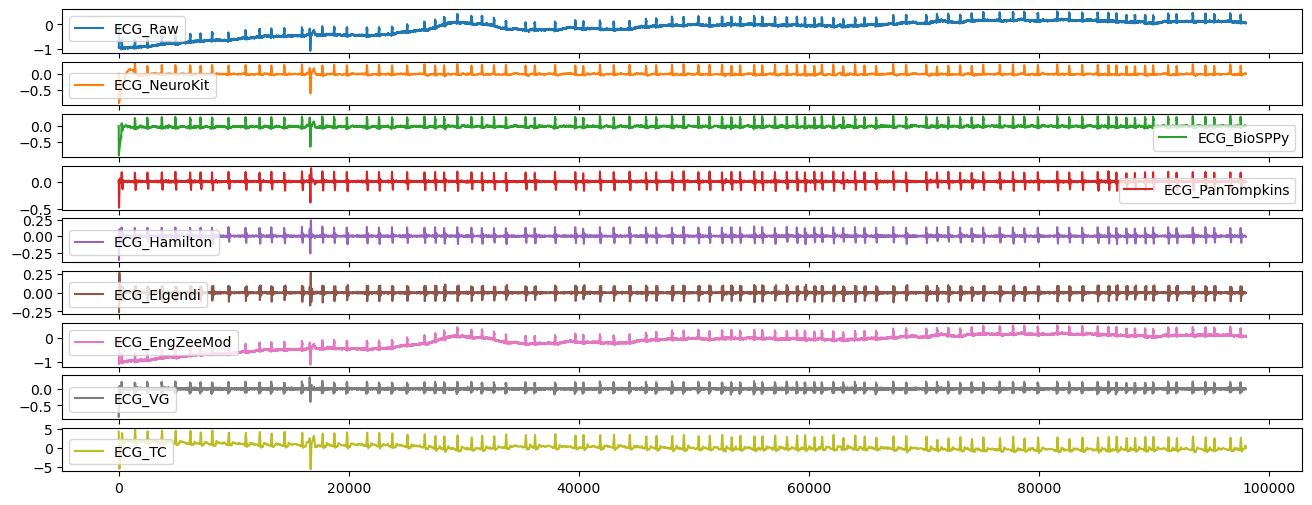

In [ ]:
signals.plot(subplots=True)

# Verificando a qualidade dos sinais

Avaliação da qualidade do sinal ECG

Avalie a qualidade do sinal de ECG usando vários métodos:

- O que é "averageQRS"o método calcula um índice contínuo de qualidade do sinal de ECG, por interpolação da distância de cada segmento QR a partir do segmento QRS médio presente no ? Os dados. Este índice é, portanto, relativo: 1 corresponde aos batimentos cardíacos que são os mais próximos de a amostra média e 0 correspondem aos batimentos cardíacos mais distantes da amostra média. Note que 1 não significa necessariamente “bom”: se a maioria das amostras é ruim, então ser perto da média provavelmente vai significar ruim também. Use este índice com cuidado e plotá-lo ao lado do seu sinal de ECG para ver se faz sentido.

- O que é "zhao2018"método (Zhao et al., 2018) extrai vários índices de qualidade de sinal (SQIs): Distribuição do espectro de energia da onda QRS PSQI, kurtosis kSQI e basSQI relativa de potência basal. Uma correspondência de detecção de pico R adicional qSQI foi originalmente computada no papel, mas deixada de fora Neste algoritmo. Os índices foram originalmente ponderados com uma proporção de [0,4, 0,4, 0,1, 0,1] para gerar o resultado final da classificação, mas porque o qSQI foi descartado, os pesos têm foi reorganizado para [0,6, 0,2] para pSQI, kSQI e basSQI respectivamente.



# Usando a função

Usando a função nk.ecg_quality(ecg_cleaned, sampling_rate=300)

- obs: o ecg_cleaned significa o sinal limpo então o sinal antes de ir para qualidade tem que ser tratado como limpo.

Parâmetros:

- ecg_cleaned (Union[listista, np.array, pd.Sariado]) – O sinal de ECG limpo na forma de um vetor de valores.

- rpeaks (tupla ou lista) – A lista de amostras de pico R retornadas por ecg_peaks()- A . (í a , , , , , ínte , . Se Nenhum, os picos são computados a partir de a entrada do sinal.

- sampling_rate (int) – A frequência de amostragem do sinal (em Hz, ou seja, amostras/segundo).

- método (str) – O método para calcular a qualidade do sinal ECG, pode ser "averageQRS"(padrão) ou "zhao2018"- A . (í a , , , , , í , .

- abordagem (str) – A abordagem de fusão de dados, conforme documentado em Zhao et al. (2018) Pode ser "simple"ou a "fuzzy"- A . (í a questão: es. , , , ínte , , . O primeiro executa a fusão heurística simples de SQIs e o último se apresenta uma avaliação abrangente. Se for None(padrão), é utilizada uma fusão heurística simples.

- ?kwargs – argumentos de palavras-chave a serem passados para signal_power()no cálculo do basSQI e do pSQI.

Devoluções:
- array ou str – Vector contendo o índice de qualidade que varia de 0 a 1 para "averageQRS"o método, Retorna a classificação de strings (Unacceptable,, , - A , de frente para o que sobre o que sobre, , sobre o que sobre o que sobre, sobre o que Barely acceptableou a Excellent) - ) do sinal para "zhao2018"método.


In [ ]:
# Exemplo 1: método “médiaQRS”
ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="neurokit")

quality = nk.ecg_quality(ecg_cleaned, sampling_rate=1000)
quality

array([0.07547457, 0.07547457, 0.07547457, ..., 0.        , 0.        ,
       0.        ])

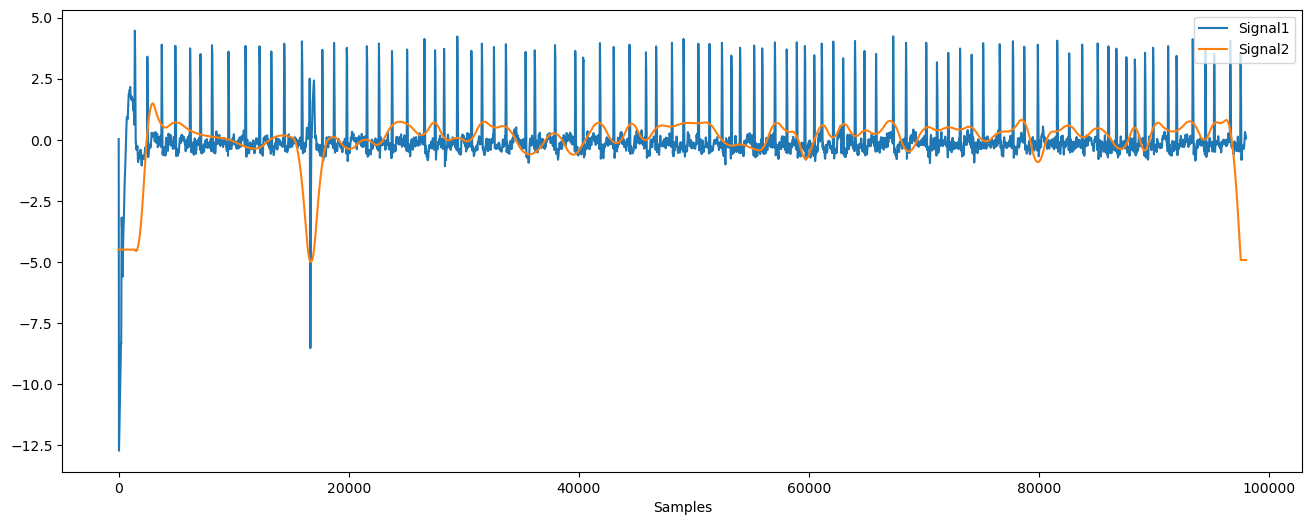

In [ ]:
nk.signal_plot([ecg_cleaned, quality], standardize=True)

In [ ]:
# Exemplo 2: Zhao et al. Método (2018)
quality_Zhao = nk.ecg_quality(ecg_cleaned, sampling_rate=1000, method="zhao2018", approach="fuzzy")
quality_Zhao

'Excellent'

Verificando a respiração de acordo com o batimento cardíaca

- Extrair ECG-Derived Respiration (EDR), um proxy de um sinal respiratório com base na frequência cardíaca.

Diferentes métodos incluem:
- vangent2019: filtro de 0.1-0.4 Hz.
- soni2019 : filtro de 0-0,5 Hz.
- charlton2016 : filtro de 0.066-1 Hz.
- sarkar2015: 0.1-0.7 Hz filtro.


Função nk.ecg_rsp(ecg_rate, sampling_rate=100)

Parâmetros:

- ecg_rate (array) – O sinal de frequência cardíaca obtido via ecg_rate()- A . (í a , , , , , í , .

- sampling_rate (int) – A frequência de amostragem do sinal que contém os picos R (em Hz, ou seja, amostras/segundo). O padrão é de 1000Hz.

- método (str) – Pode ser um dos "vangent2019"(default), "soni2019",, , - A , de frente para o que sobre o que sobre, "charlton2016"ou a "sarkar2015"- A . (í a , , , , , í

Devoluções:
- matriz – Uma matriz Numpy contendo a frequência respiratória derivada.


In [ ]:
# tem que ter uma base de dados EDR
# rpeaks, info = nk.ecg_peaks('base de dados EDR', sampling_rate=1000)

# ecg_rate = nk.signal_rate(rpeaks, sampling_rate=1000, desired_length=len(rpeaks))

# ECG Derived Respiration (EDR) and add to the data

# data["EDR"] = nk.ecg_rsp(ecg_rate, sampling_rate=100)

# # Visualize result

# nk.signal_plot([data["RSP"], data["EDR"]], standardize = True)

#Encontre R-picos em um sinal de ECG


- Encontre R-picos em um sinal de ECG usando o método especificado. Você pode passar um ECG não filtrado sinais como entrada, mas tipicamente um ECG filtrado (limpo usando ecg_clean()) resultará em melhores resultados.


Parâmetros:
- ecg_cleaned (Union[listista, np.array, pd.Series]) – O canal de ECG limpo como retornado por ecg_clean()- A . (í a , , , , , ínte , .
- sampling_rate (int) – A frequência de amostragem de ecg_cleaned(em Hz, ou seja, amostras/segundo). O padrão é de 1000.
- método (string) – O algoritmo a ser usado para detecção de pico R.
- corrigir_artifacts (bool) – Quer identificar ou não e corrigir artefatos, usando o método por Lipponen & Tarvainen (2019) (em inglês).
- show (bool) – Se True, vai mostrar um gráfico do sinal com picos. Demplôm-se a False- A . (í a , , , , , í , .
- ?kwargs – Discussões de palavras-chave adicionais, geralmente específicas para cada método.


Devoluções:
- sinais (DataFrame) – Um DataFram de mesmo comprimento que o sinal de entrada no qual as ocorrências de R-picos marcados como 1em uma lista de zeros com o mesmo comprimento que ecg_cleaned- A . (í a , , , , , í , . Acessível com as chaves "ECG_R_Peaks"- A . (í a , , , , , í , .
- info (dd) – Um dicionário contendo informações adicionais, neste caso as amostras em que R-picos ocorrer, acessível com a chave "ECG_R_Peaks", assim como a taxa de amostragem dos sinais, Acessível com a chave "sampling_rate"- A . (í a , , , , , í , .




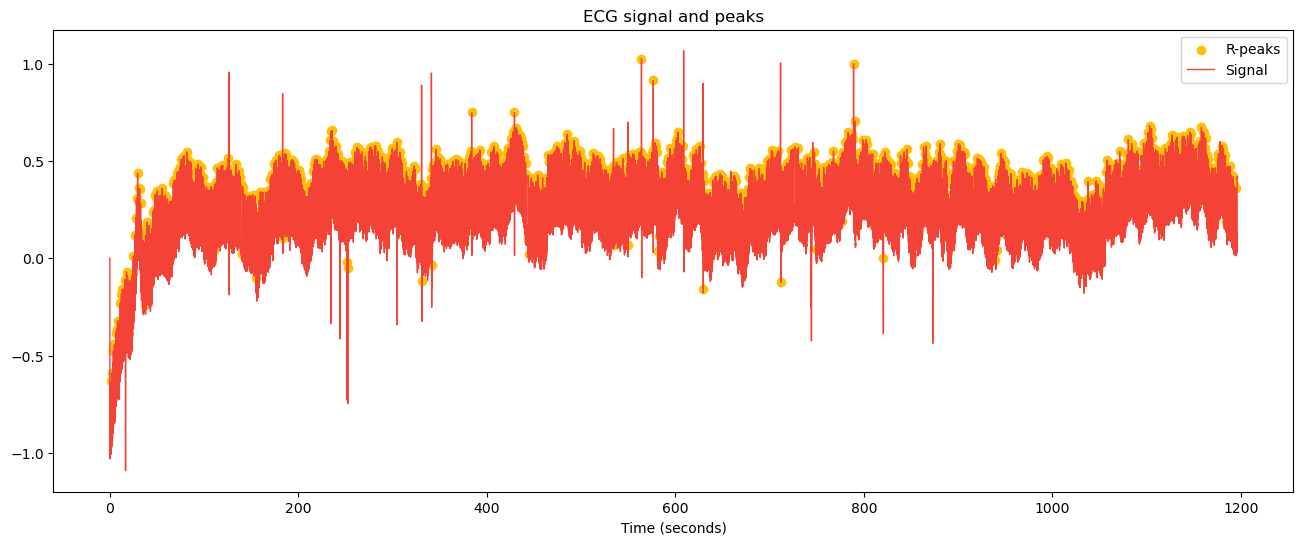

In [ ]:

# ecg_peaks()

signals, info = nk.ecg_peaks(p_signal[:,0], sampling_rate=1000, correct_artifacts=True, show=True)

In [ ]:
signals

,ECG_R_Peaks
0,0
1,0
2,0
3,0
4,0
...,...
1195995,0
1195996,0
1195997,0
1195998,0


In [ ]:
info

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([   1396,    2485,    3736, ..., 1192957, 1193902, 1194990]),
 'ECG_R_Peaks_Uncorrected': array([   1396,    2485,    3736, ..., 1192957, 1193902, 1194990]),
 'ECG_fixpeaks_ectopic': [],
 'ECG_fixpeaks_missed': [],
 'ECG_fixpeaks_extra': [],
 'ECG_fixpeaks_longshort': [],
 'ECG_fixpeaks_method': 'kubios',
 'ECG_fixpeaks_rr': array([1.09403666, 1.089     , 1.251     , ..., 0.997     , 0.945     ,
        1.088     ]),
 'ECG_fixpeaks_drrs': array([-7.46713524e-06, -6.89387300e-03,  2.23125129e-01, ...,
        -5.21978022e-01, -6.16332820e-02,  1.67555217e-01]),
 'ECG_fixpeaks_mrrs': array([-0.13222428, -0.01478659,  0.16480255, ..., -0.08099508,
        -0.25389498,  0.04025302]),
 'ECG_fixpeaks_s12': array([-6.89387300e-03, -7.46713524e-06, -6.89387300e-03, ...,
        -6.16332820e-02, -5.21978022e-01, -6.16332820e-02]),
 'ECG_fixpeaks_s22': array([ 0.22312513,  0.22312513, -0.09049774, ...,  0.16755522,
  

C:\Users\daniel.odossantos\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\daniel.odossantos\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


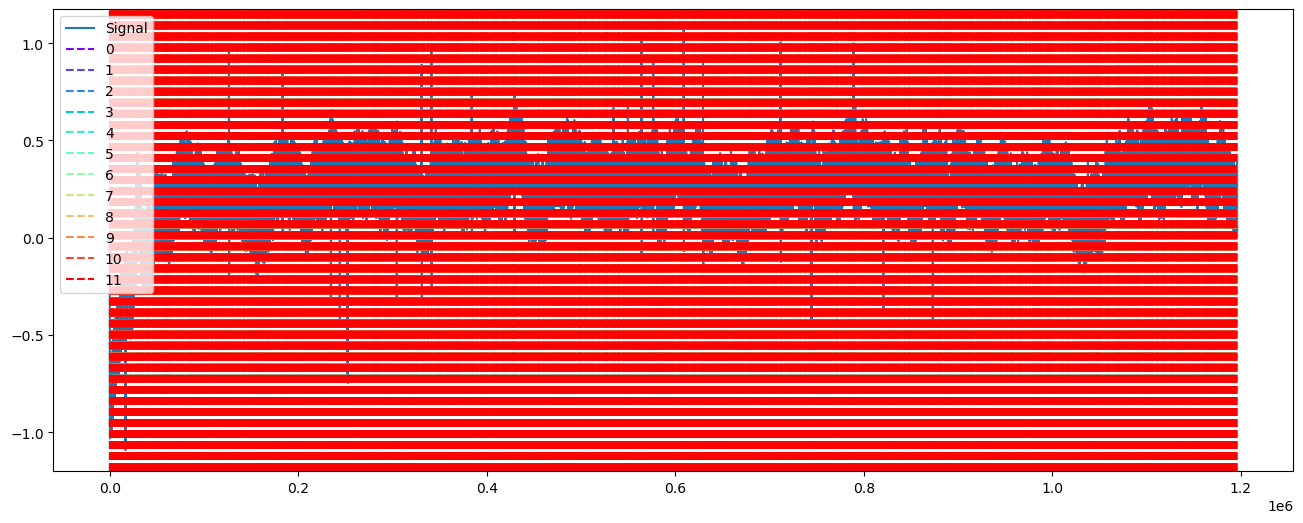

In [ ]:
# Exemplo 2: Comparar métodos diferentes

ecg = p_signal[:,0]

# neurokit (default)
cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="neurokit")

_, neurokit = nk.ecg_peaks(cleaned, sampling_rate=1000, method="neurokit")

# pantompkins1985

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="pantompkins1985")

_, pantompkins1985 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="pantompkins1985")

# hamilton2002

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="hamilton2002")

_, hamilton2002 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="hamilton2002")

# zong2003

_, zong2003 = nk.ecg_peaks(ecg, sampling_rate=1000, method="zong2003")

# martinez2004

_, martinez2004 = nk.ecg_peaks(ecg, sampling_rate=1000, method="martinez2004")

# christov2004

_, christov2004 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="christov2004")

# gamboa2008

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="gamboa2008")

_, gamboa2008 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="gamboa2008")

# elgendi2010

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="elgendi2010")

_, elgendi2010 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="elgendi2010")

# engzeemod2012

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="engzeemod2012")

_, engzeemod2012 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="engzeemod2012")

# Manikandan (2012)

_, manikandan2012 = nk.ecg_peaks(ecg, sampling_rate=1000, method="manikandan2012")

# kalidas2017

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="kalidas2017")

_, kalidas2017 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="kalidas2017")

# nabian2018

_, nabian2018 = nk.ecg_peaks(ecg, sampling_rate=1000, method="nabian2018")

# rodrigues2021

_, rodrigues2021 = nk.ecg_peaks(ecg, sampling_rate=1000, method="rodrigues2021")

# emrich2023

cleaned = nk.ecg_clean(ecg, sampling_rate=1000, method="emrich2023")

_, emrich2023 = nk.ecg_peaks(cleaned, sampling_rate=1000, method="emrich2023")

# Collect all R-peak lists by iterating through the result dicts

rpeaks = [
    i["ECG_R_Peaks"]

    for i in [

        neurokit,

        pantompkins1985,

        nabian2018,

        hamilton2002,

        martinez2004,

        christov2004,

        gamboa2008,

        elgendi2010,

        engzeemod2012,

        kalidas2017,

        rodrigues2021,

        emrich2023

    ]

]



# Visualize results

nk.events_plot(rpeaks, ecg)